In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import backend as K
#from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy
import os

sys.path.insert(0,'../../scripts/tools_for_VAE/')
import tools_for_VAE.model
#from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot

%matplotlib inline
%config InlineBackend.figure_format='retina'

W0507 20:22:24.202095 139790734182208 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/singularity5/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


In [18]:
import cProfile

In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    # Restrict TensorFlow to only allocate 8GB of memory on the first GPU
    try:
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=8192)])
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Virtual devices must be set before GPUs have been initialized
        print(e)
        
tf.config.set_soft_device_placement(True)
tf.debugging.set_log_device_placement(True)

conda list

In [3]:
######## Parameters
nb_of_bands = 6
batch_size = 256

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

%conda install fftw

%pip install eigency

%pip install cython

## Load data

In [4]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/training_24.5_v2/' # mag cut at 24.5 in r band
#root_dir_v2 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_26.5/' # mag cut at 26.5 in r band

In [5]:
images_noiseless = np.load(root_dir_v1+'img_noiseless_sample_1.npy', mmap_mode = 'c') # artificial augmentation of pixel intensity. Residual from tests, needs to be suppressed
images_blend = np.load(root_dir_v1+'img_cropped_sample_1.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_1.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_1.csv')

images_noiseless = images_noiseless[:2000]
images_blend = images_blend[:2000]
psf = psf[:2000]

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

## Load VAE to train deblender

In [6]:
from platform import python_version

print(python_version())

3.6.7


%pip install galsim

In [7]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Lambda, Layer, Multiply, Reshape, Flatten, BatchNormalization, Conv2D, Conv3D, UpSampling2D, Cropping2D, Conv2DTranspose, PReLU, Concatenate, Lambda,  concatenate
import tensorflow_probability as tfp

In [8]:
tfd = tfp.distributions
tfb = tfp.bijectors
encoded_size = 32
prior = tfd.Independent(tfd.Normal(loc=tf.zeros(encoded_size), scale=1),reinterpreted_batch_ndims=1)

def create_model_wo_ls_peak_pooling_vae(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None):
    input_layer_1 = Input(shape=(input_shape)) 
    input_layer_2 = Input(shape=(input_shape)) 

    h = BatchNormalization()(input_layer_1)
    #h = input_layer_1
    h_2 = input_layer_2
    for i in range(len(filters)):
        h_2 = Conv2D(filters[i], (kernels[i],kernels[i]), activation=None, padding='same')(h_2)
        h_2 = PReLU()(h_2)
        h = Conv2D(filters[i], (kernels[i],kernels[i]), activation=None, padding='same', strides=(2,2))(h)
        h = PReLU()(h)

        h = Conv2D(filters[i], (kernels[i],kernels[i]), activation=None, padding='same')(h)
        h = PReLU()(h)
        h_2 = Conv2D(filters[i], (kernels[i],kernels[i]), activation=None, padding='same', strides=(2,2))(h_2)
        h_2 = PReLU()(h_2)

    h = tf.keras.layers.concatenate([tf.cast(h,tf.float64), tf.cast(h_2,tf.float64)], axis =-1)
    h = Flatten()(h)
    h = PReLU()(h)
    h = Dense(256)(h)
    h = PReLU()(h)
    h = Dense(tfp.layers.MultivariateNormalTriL.params_size(32),
                activation=None)(h)
    h = tfp.layers.MultivariateNormalTriL(32,activity_regularizer=tfp.layers.KLDivergenceRegularizer(prior, weight=0.01))(tf.cast(h,tf.float32))#,activity_regularizer=tfp.layers.KLDivergenceRegularizer(prior, weight=0.001)
    
    
    
    h = PReLU()(h)
    h = Dense(256)(h)
    h = PReLU()(h)
    #h = tf.keras.layers.Lambda(lambda x: tf.signal.ifft(tf.cast(x, tf.complex64), name=None))(h)
    w = int(np.ceil(input_shape[0]/2**(len(filters))))
    h = Dense(w*w*filters[-1], activation=dense_activation)(tf.cast(h,tf.float32))
    h = PReLU()(h)
    h = Reshape((w,w,filters[-1]))(h)
    for i in range(len(filters)-1,-1,-1):
        h = Conv2DTranspose(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same', strides=(2,2))(h)
        h = PReLU()(h)
        #h = tf.keras.layers.UpSampling2D()(h)
        h = Conv2DTranspose(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same')(h)
        h = PReLU()(h)
    h = Conv2D(input_shape[-1], (3,3), activation='sigmoid', padding='same')(h)
    #h = PReLU()(h)
    cropping = int(h.get_shape()[1]-input_shape[0])
    if cropping>0:
        print('in cropping')
        if cropping % 2 == 0:
            h = Cropping2D(cropping/2)(h)
        else:
            h = Cropping2D(((cropping//2,cropping//2+1),(cropping//2,cropping//2+1)))(h)


    model = Model([input_layer_1, input_layer_2],h)

    return model

In [9]:
path_output = '/pbs/home/b/barcelin/sps_link/TFP/weights/test_dc2/v19/mse/'
net = create_model_wo_ls_peak_pooling_vae(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0507 20:22:26.360147 139790734182208 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/singularity5/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0507 20:22:26.822961 139790734182208 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/singularity5/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


in cropping


In [10]:
latest = tf.train.latest_checkpoint(path_output)
net.load_weights(latest)

In [11]:
#### Loss definition
model_loss = 'crossentropy'
if model_loss == 'mse':
    vae_loss = tf.keras.losses.MeanSquaredError()
elif model_loss == 'crossentropy':
    def vae_loss(x, x_decoded_mean):
        xent_loss = K.mean(K.sum(K.binary_crossentropy(x, x_decoded_mean), axis=[1,2,3]))
        #x_res = K.mean(K.sum(K.binary_crossentropy(x, x-x_decoded_mean), axis=[1,2,3]))
        return xent_loss


# Custom metrics
def kl_metric(y_true, y_pred):
    return K.sum(net.losses)
mse = tf.keras.losses.MeanSquaredError()

In [12]:
net.layers[44:]

In [13]:
images_blend = np.tanh(np.arcsinh(images_blend))
images_noiseless = np.tanh(np.arcsinh(images_noiseless))
psf = np.tanh(np.arcsinh(psf))

In [14]:
for i in range (len(net.layers[44:])):
                net.layers[44+i].trainable = False

In [15]:
print("trainable_weights:", len(net.trainable_weights))
print("non_trainable_weights:", len(net.non_trainable_weights))

trainable_weights: 56
non_trainable_weights: 35


In [16]:
# Profile from batches 10 to 15
#log_dir = "/pbs/home/b/barcelin/sps_link/data/log_test/"
#tb_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,
#                                             profile_batch='1, 2')


In [17]:
net.compile(optimizer=tf.optimizers.Adam(learning_rate=1e-4), 
              loss=vae_loss,
              metrics = ['mse', 'acc',kl_metric],
              #experimental_run_tf_function=False,
              )

net.summary()

In [21]:
######## Train the network
## With dataset (faster than directly from generator)
hist = net.fit((images_blend, psf), images_noiseless, epochs=20,#training_ds
                    batch_size=batch_size,
                    verbose=1,
                    shuffle=True,
                    validation_data=((images_blend, psf), images_noiseless),#validation_ds
                    validation_steps=3,)
                    #callbacks=[tb_callback])

Train on 2000 samples, validate on 2000 samples
Epoch 1/20
2000/2000 [==============================] - 26s 13ms/sample - loss: 1023.1257 - mean_squared_error: 4.6502e-04 - acc: 0.9211 - kl_metric: 0.4585 - val_loss: 1017.6053 - val_mean_squared_error: 3.8860e-04 - val_acc: 0.9215 - val_kl_metric: 0.4568
Epoch 2/20
2000/2000 [==============================] - 13s 6ms/sample - loss: 1015.9127 - mean_squared_error: 3.8460e-04 - acc: 0.9218 - kl_metric: 0.4709 - val_loss: 1014.0558 - val_mean_squared_error: 3.4634e-04 - val_acc: 0.9211 - val_kl_metric: 0.4721
Epoch 3/20
2000/2000 [==============================] - 13s 6ms/sample - loss: 1011.1879 - mean_squared_error: 3.2624e-04 - acc: 0.9212 - kl_metric: 0.4673 - val_loss: 1009.1470 - val_mean_squared_error: 3.0528e-04 - val_acc: 0.9213 - val_kl_metric: 0.4601
Epoch 4/20
2000/2000 [==============================] - 13s 6ms/sample - loss: 1007.3246 - mean_squared_error: 2.9065e-04 - acc: 0.9218 - kl_metric: 0.4441 - val_loss: 1006.1282 - 

In [22]:
output = net([tf.cast(images_blend, tf.float32), tf.cast(psf, tf.float32)])

In [23]:
output = K.get_value(output)

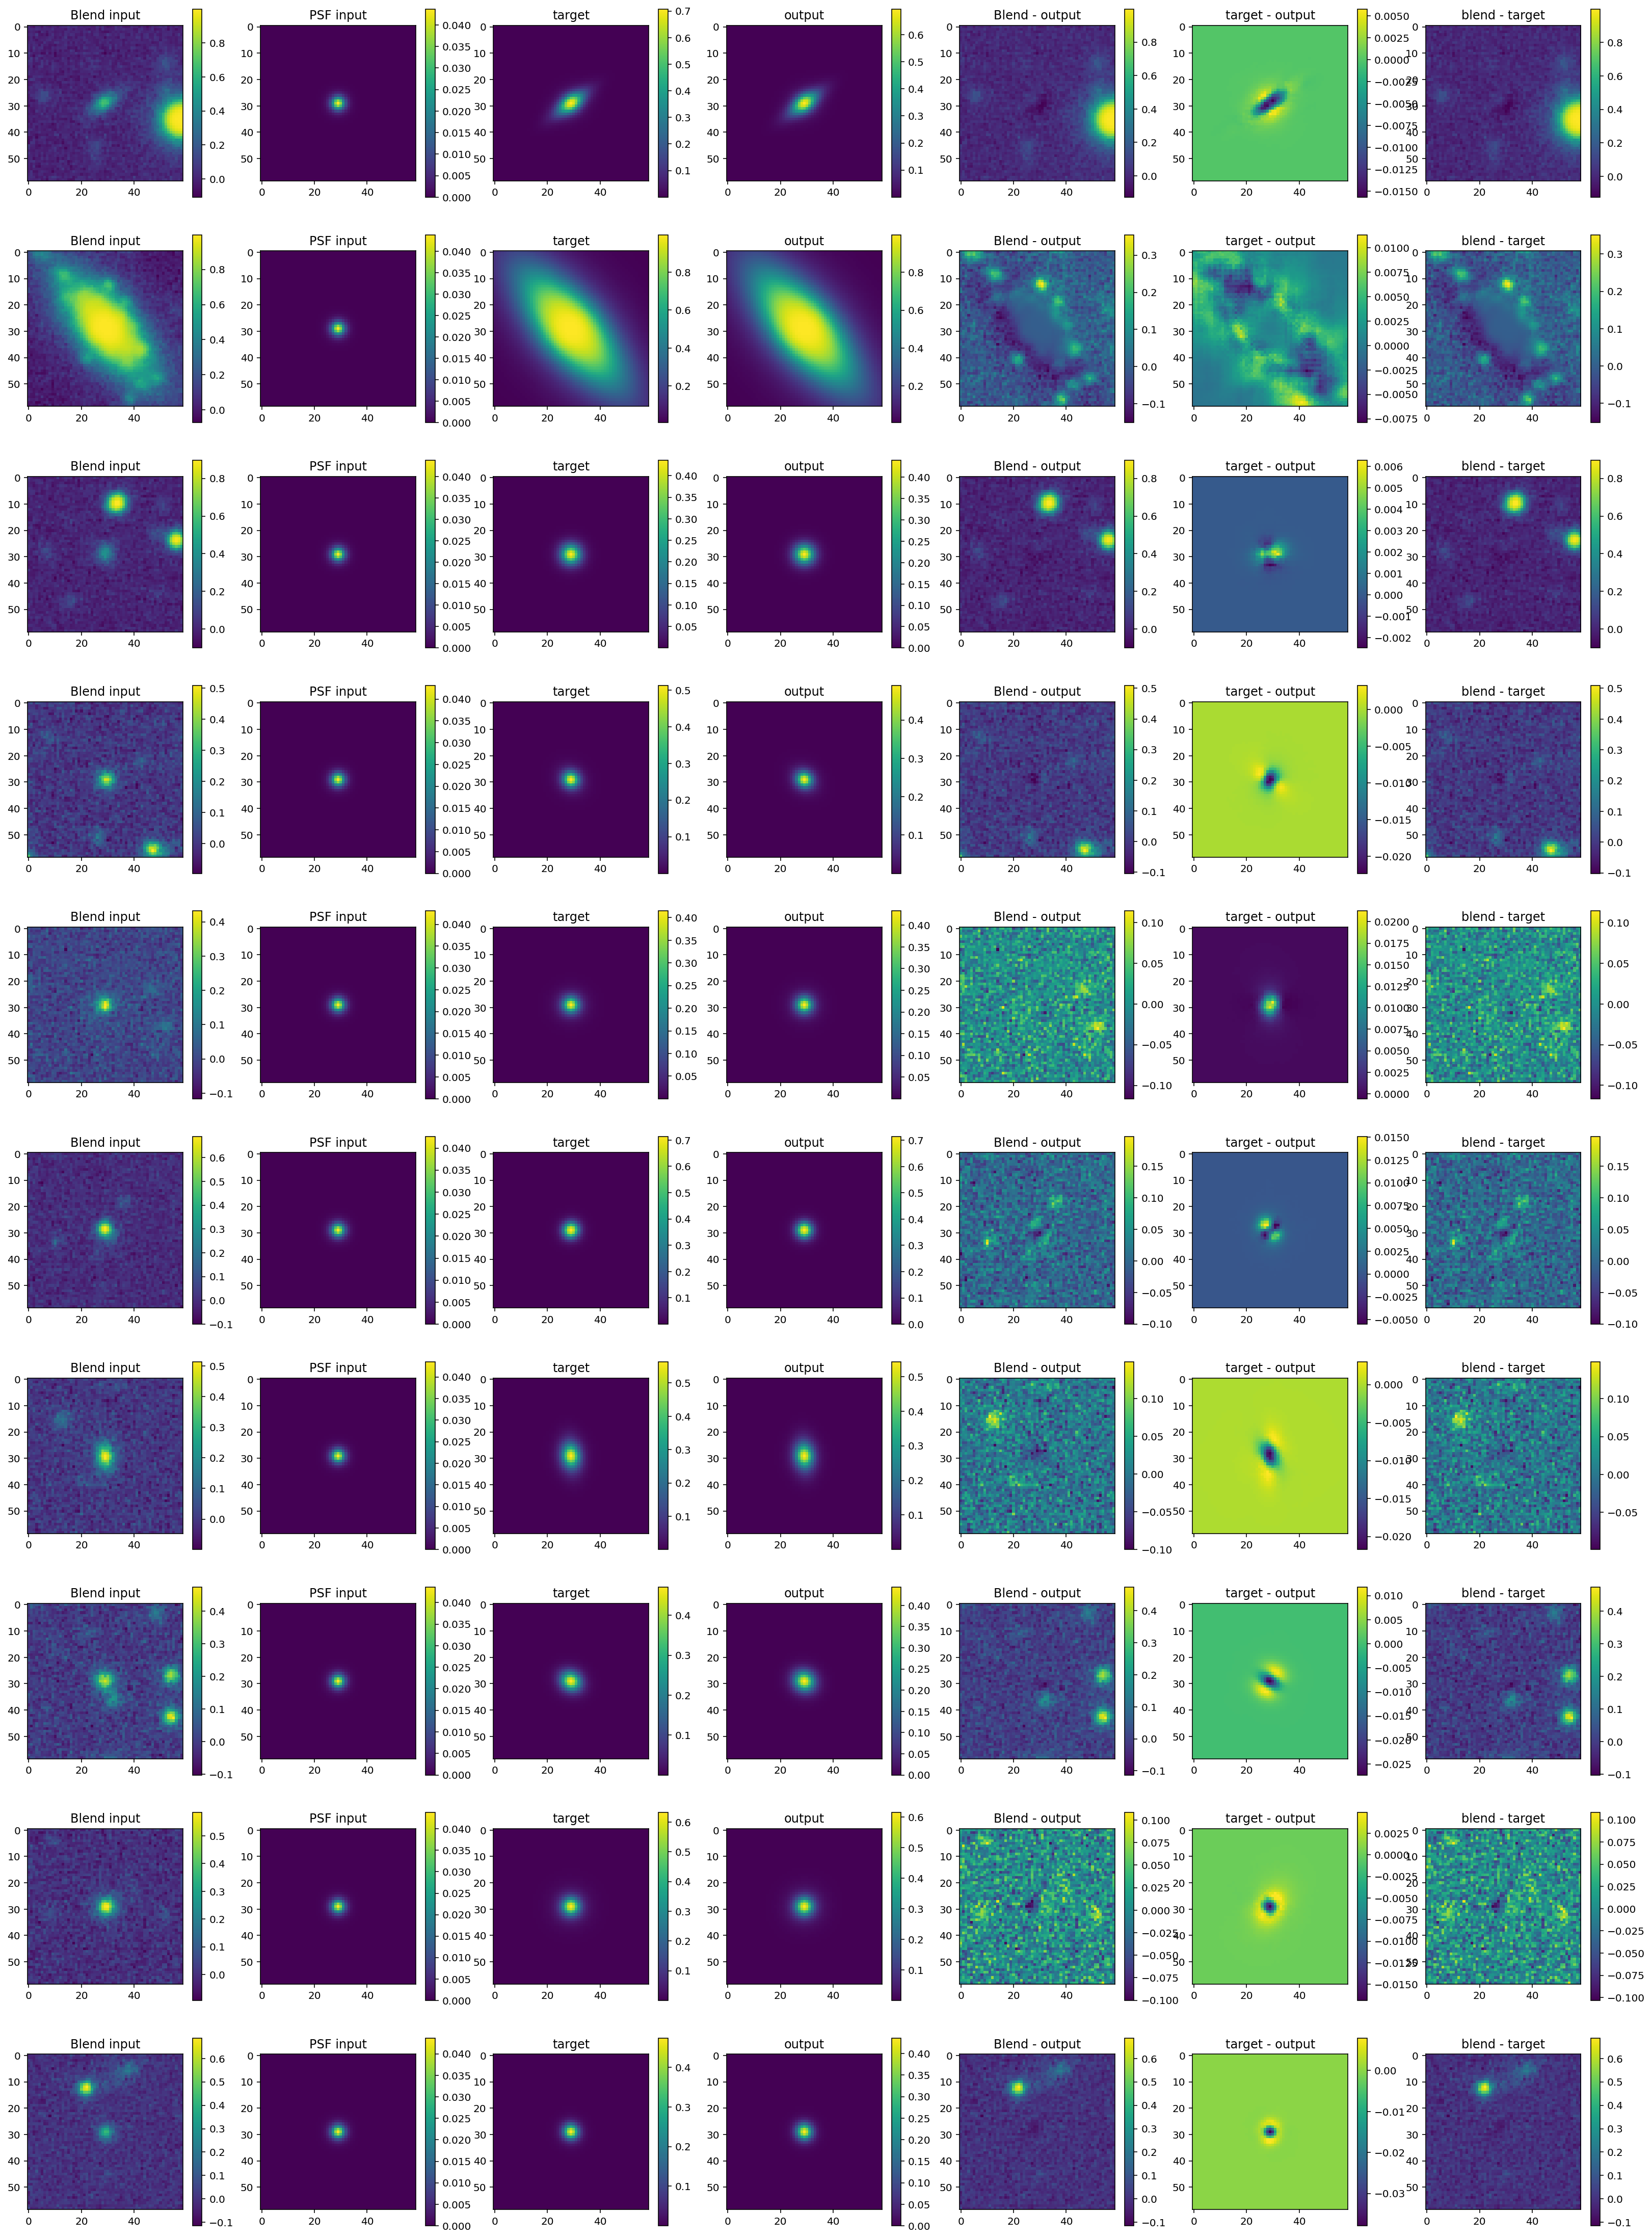

In [84]:
fig, axes = plt.subplots(10,7, figsize = (28, 40))

for i in range (10):
    f1 = axes[i,0].imshow(images_blend[i,:,:,2])
    f2 = axes[i,1].imshow(psf[i,:,:,2])
    f3 = axes[i,2].imshow(output[i,:,:,2])
    f4 = axes[i,3].imshow(images_noiseless[i,:,:,2])
    f5 = axes[i,4].imshow(images_blend[i,:,:,2] - output[i,:,:,2])
    f6 = axes[i,5].imshow(images_noiseless[i,:,:,2] - output[i,:,:,2])
    f7 = axes[i,6].imshow(images_blend[i,:,:,2] - images_noiseless[i,:,:,2])
    
    fig.colorbar(f1, ax = axes[i,0])
    fig.colorbar(f2, ax = axes[i,1])
    fig.colorbar(f3, ax = axes[i,2])
    fig.colorbar(f4, ax = axes[i,3])
    fig.colorbar(f5, ax = axes[i,4])
    fig.colorbar(f6, ax = axes[i,5])
    fig.colorbar(f7, ax = axes[i,6])
    
    axes[i,0].set_title('Blend input')
    axes[i,1].set_title('PSF input')
    axes[i,2].set_title('target')
    axes[i,3].set_title('output')
    axes[i,4].set_title('Blend - output')
    axes[i,5].set_title('target - output')
    axes[i,6].set_title('blend - target')

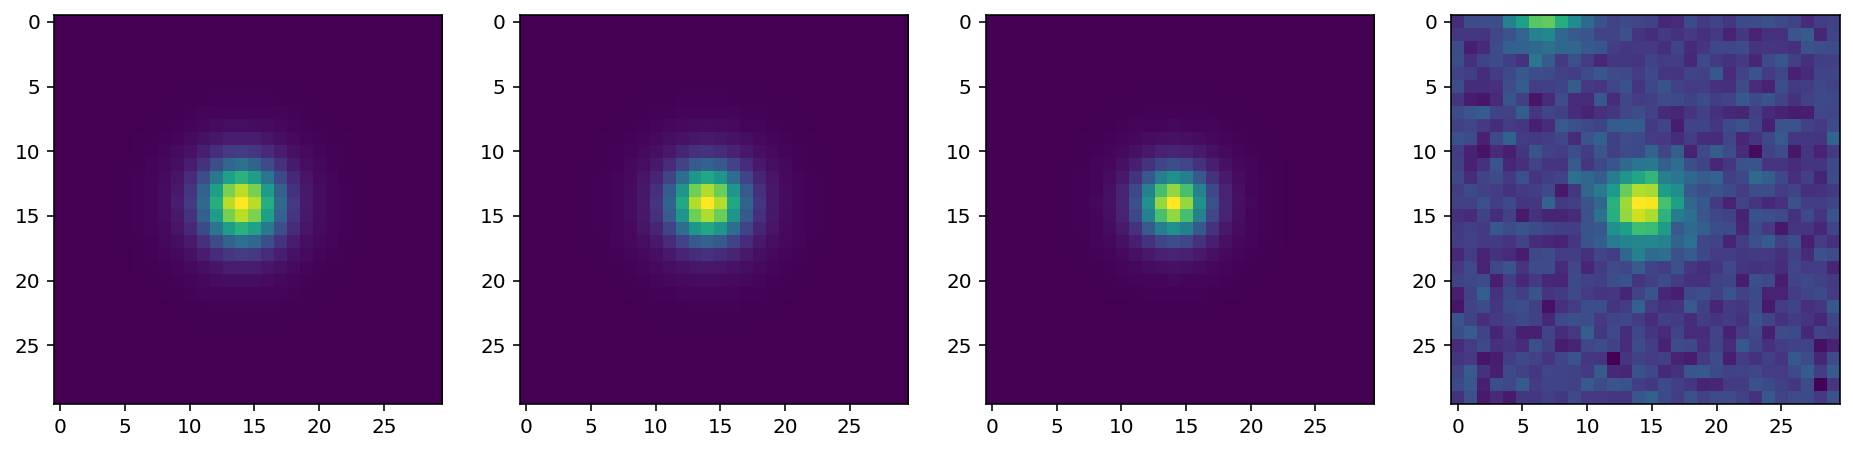

In [71]:
fig, axes = plt.subplots(1,4, figsize = (16,4))

axes[0].imshow(images_noiseless[i,15:45,15:45,2])
axes[1].imshow(output[i,15:45,15:45,2])
axes[2].imshow(psf[i,15:45,15:45,2])
axes[3].imshow(images_blend[i,15:45,15:45,2])

%pip install scikit-image

## Image reconstruction metrics from https://github.com/LSSTDESC/BlendingToolKit/blob/main/btk/metrics.py

In [21]:
import skimage
#import skimage.metrics

KeyboardInterrupt: 

In [26]:
mse = skimage.metrics.mean_squared_error(images_noiseless, output)
print(mse)

AttributeError: module 'skimage' has no attribute 'metrics'

In [ ]:
psnr = skimage.metrics.peak_signal_noise_ratio(images_noiseless, output, data_range=np.max(images_noiseless))
print(psnr)

In [ ]:
ssim = skimage.metrics.structural_similarity(images_noiseless, output, multichannel = True)
print(ssim)

### Test with batch generator to do profiling

In [22]:
import tensorflow

In [23]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

In [24]:
class BatchGenerator_dc2_deconv_vae(tensorflow.keras.utils.Sequence):
    """
    Class to create batch generator for the LSST VAE.
    """
    def __init__(self, bands,path, list_of_samples,total_sample_size, batch_size, trainval_or_test, do_norm,denorm, list_of_weights_e):
        """
        Initialization function
        total_sample_size: size of the whole training (or validation) sample
        batch_size: size of the batches to provide
        list_of_samples: list of the numpy arrays which correspond to the whole training (or validation) sample
#        path: path to the first numpy array taken in which the batch will be taken
        training_or_validation: choice between training of validation generator
        x: input of the neural network
        y: target of the neural network
        r: random value to sample into the validation sample
        """
        self.bands = bands
        self.nbands = len(bands)
        self.total_sample_size = total_sample_size
        self.batch_size = batch_size
        self.list_of_samples = list_of_samples
        self.trainval_or_test = trainval_or_test
        self.path = path
        
        self.epoch = 0
        self.do_norm = do_norm
        self.denorm = denorm

        # Weights computed from the lengths of lists
        self.p = []
        for sample in self.list_of_samples:
            temp = np.load(sample, mmap_mode = 'c')
            self.p.append(float(len(temp)))
        self.p = np.array(self.p)
        self.total_sample_size = int(np.sum(self.p))
        print("[BatchGenerator] total_sample_size = ", self.total_sample_size)
        print("[BatchGenerator] len(list_of_samples) = ", len(self.list_of_samples))

        self.p /= np.sum(self.p)

        self.produced_samples = 0
        self.list_of_weights_e = list_of_weights_e
        #self.shifts = shifts

    def __len__(self):
        """
        Function to define the length of an epoch
        """
        return int(float(self.total_sample_size) / float(self.batch_size))      

    def on_epoch_end(self):
        """
        Function executed at the end of each epoch
        """
        # indices = 0
        #print("Produced samples", self.produced_samples)
        self.produced_samples = 0
        
    def __getitem__(self, idx):
        """
        Function which returns the input and target batches for the network
        """
        # If the generator is a training generator, the whole sample is displayed
        sample_filename = np.random.choice(self.list_of_samples, p=self.p)
        #index = np.random.choice(1)
        #index = np.random.choice(list(range(len(self.p))), p=self.p)
        #sample_filename = self.list_of_samples[index]

        sample = np.load(sample_filename, mmap_mode = 'c')
        sample_dc2 = np.load(sample_filename.replace('img_noiseless_sample','img_cropped_sample'), mmap_mode = 'c')
        data = pd.read_csv(sample_filename.replace('img_noiseless_sample','img_noiseless_data').replace('.npy','.csv'))
        psf = np.load(sample_filename.replace('img_noiseless_sample','psf_cropped_sample'), mmap_mode = 'c')
        #print(len(data['e1']))
        data['weights']=(np.abs(data['e1'])+np.abs(data['e2']))
        new_data = data[(np.abs(data['e1'])<=1.) &
                        (np.abs(data['e2'])<=1.)]# &
                        #(data['snr_r']>20)]#snr_r
                        #(np.abs(data['blendedness'])==0.)]# &
        #print(len(new_data['e1']))
        
        if self.list_of_weights_e == None:
            indices = np.random.choice(new_data.index, size=self.batch_size, replace=False, p = new_data['weights']/np.sum(new_data['weights']))
        else:
            self.weights_e = np.load(self.list_of_weights_e[index])
            indices = np.random.choice(new_data.index, size=self.batch_size, replace=False, p = self.weights_e/np.sum(self.weights_e))

        self.produced_samples += len(indices)
        
        ell_1 = np.array(new_data['e1'][indices])
        ell_2 = np.array(new_data['e2'][indices])
        shear_1 = np.array(new_data['shear_1'][indices])
        shear_2 = np.array(new_data['shear_2'][indices])
        convergence = np.array(new_data['convergence'][indices])
        
        ellipticity = calc_lensed_ellipticity(ell_1, ell_2, shear_1, shear_2, convergence)
        ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

        ellipticity_1 = ellipticity_conversion(calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence))
        ellipticity_2 = ellipticity_conversion(calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence))

        x_1 = np.tanh(np.arcsinh(sample_dc2[indices][:,:,:,self.bands]))
        x_3 = np.tanh(np.arcsinh(sample[indices][:,:,:,self.bands]))
        x_2 = psf[indices][:,:,:,self.bands]
        y = np.zeros((self.batch_size, 2))

        #flip : flipping the image array
        rand = np.random.randint(4)
        if rand == 1: 
            x_1 = np.flip(x_1, axis=2)
            x_2 = np.flip(x_2, axis=2)
            x_3 = np.flip(x_3, axis=2)
            y[:,0] = -ellipticity_1
            y[:,1] = -ellipticity_2
        elif rand == 2:
            x_1 = np.swapaxes(x_1, 2, 1)
            x_2 = np.swapaxes(x_2, 2, 1)
            x_3 = np.swapaxes(x_3, 2, 1)
            y[:,0] = +ellipticity_1
            y[:,1] = ellipticity_2
        elif rand == 3:
            x_1 = np.swapaxes(np.flip(x_1, axis=2), 2, 1)
            x_2 = np.swapaxes(np.flip(x_2, axis=2), 2, 1)
            x_3 = np.swapaxes(np.flip(x_3, axis=2), 2, 1)
            y[:,0] = +ellipticity_1
            y[:,1] = -ellipticity_2
        else:
            y[:,0] = -ellipticity_1
            y[:,1] = ellipticity_2
        if len(self.bands)==1:
            x_1 = np.expand_dims(x_1, axis=-1)
            x_2 = np.expand_dims(x_2, axis=-1)
            x_3 = np.expand_dims(x_3, axis=-1)

        #print(y)
        #x_1 = np.arcsinh(x_1/0.01)
        if self.trainval_or_test == 'training' or self.trainval_or_test == 'validation':
            return (x_1, x_2), x_3
        elif self.trainval_or_test == 'test':
            return (x_1, x_2), x_3

In [25]:
def training_batch_generator():
    multi_enqueuer = tf.keras.utils.OrderedEnqueuer(training_generator,
                                                use_multiprocessing=False)
    multi_enqueuer.start(workers=10, max_queue_size=10)
    while True:
        batch_x, batch_y = next(multi_enqueuer.get())
        yield batch_x, batch_y

# Recommended to specify the expected output shapes and types here
output_types = ((tf.float32,tf.float32), tf.float32)
output_shapes = ((tf.TensorShape([batch_size, 59, 59, nb_of_bands]),tf.TensorShape([batch_size, 59, 59, nb_of_bands])),
                tf.TensorShape([batch_size, 59, 59, nb_of_bands]))

training_ds = tf.data.Dataset.from_generator(training_batch_generator,
                                                output_types=output_types,
                                                output_shapes=output_shapes).repeat()

In [26]:
def listdir_fullpath(d):
    return [os.path.join(d, f) for f in os.listdir(d)]

images_dir = '/pbs/home/b/barcelin/sps_link/data/dc2_test/'#1_matching/'#deconv_conv_24.5/

list_of_samples = [x for x in listdir_fullpath(os.path.join(images_dir,'training_24.5_v2/')) if x.startswith(os.path.join(images_dir,'training_24.5_v2/')+'img_noiseless_sample')][:1]

In [27]:
training_generator = BatchGenerator_dc2_deconv_vae(bands,
                                        images_dir,
                                        list_of_samples, 
                                        total_sample_size=None,
                                        batch_size=batch_size, 
                                        trainval_or_test='training',
                                        do_norm=False,
                                        denorm = False,
                                        list_of_weights_e=None)

[BatchGenerator] total_sample_size =  10000
[BatchGenerator] len(list_of_samples) =  1


In [58]:
hist = net.fit(training_generator, epochs=10,#training_ds
                    steps_per_epoch=int(2000/256),
                    verbose=1,
                    shuffle=True,
                    #callbacks = callbacks,
                    validation_data=training_generator,#validation_ds
                    validation_steps=3)

Epoch 1/10
7/7 [==============================] - 9s 1s/step - loss: 931.8735 - mean_squared_error: 1.6284e-04 - acc: 0.9010 - kl_metric: 0.5503 - val_loss: 979.9635 - val_mean_squared_error: 2.9996e-04 - val_acc: 0.8996 - val_kl_metric: 0.5547
Epoch 2/10
7/7 [==============================] - 9s 1s/step - loss: 905.4892 - mean_squared_error: 1.6364e-04 - acc: 0.9068 - kl_metric: 0.5573 - val_loss: 925.6674 - val_mean_squared_error: 1.4757e-04 - val_acc: 0.9064 - val_kl_metric: 0.5677
Epoch 3/10
7/7 [==============================] - 9s 1s/step - loss: 944.0081 - mean_squared_error: 4.3318e-04 - acc: 0.9078 - kl_metric: 0.5371 - val_loss: 895.6079 - val_mean_squared_error: 2.1731e-04 - val_acc: 0.9021 - val_kl_metric: 0.5214
Epoch 4/10
7/7 [==============================] - 9s 1s/step - loss: 926.9304 - mean_squared_error: 3.4495e-04 - acc: 0.8975 - kl_metric: 0.5410 - val_loss: 862.8560 - val_mean_squared_error: 2.5531e-04 - val_acc: 0.8821 - val_kl_metric: 0.5493
Epoch 5/10
7/7 [====

In [ ]:
hist = net.fit(training_ds, 
                epochs=10,#training_ds
                steps_per_epoch=int(2000/256),
                verbose=1,
                shuffle=True,
                #callbacks = callbacks,
                validation_data=training_ds,#validation_ds
                validation_steps=3)

Train on 7 steps, validate on 3 steps
Epoch 1/10
7/7 [==============================] - 20s 3s/step - loss: 891.1245 - mean_squared_error: 1.2227e-04 - acc: 0.8986 - kl_metric: 0.5566 - val_loss: 935.3646 - val_mean_squared_error: 1.3523e-04 - val_acc: 0.9053 - val_kl_metric: 0.5654
Epoch 2/10
7/7 [==============================] - 11s 2s/step - loss: 881.1509 - mean_squared_error: 1.6199e-04 - acc: 0.9017 - kl_metric: 0.5486 - val_loss: 966.2236 - val_mean_squared_error: 1.6417e-04 - val_acc: 0.9129 - val_kl_metric: 0.5412
Epoch 3/10
7/7 [==============================] - 16s 2s/step - loss: 944.5797 - mean_squared_error: 1.4862e-04 - acc: 0.9026 - kl_metric: 0.5215 - val_loss: 882.8358 - val_mean_squared_error: 1.1276e-04 - val_acc: 0.9030 - val_kl_metric: 0.5245
Epoch 4/10
7/7 [==============================] - 50s 7s/step - loss: 880.8136 - mean_squared_error: 1.1018e-04 - acc: 0.9020 - kl_metric: 0.5330 - val_loss: 913.9451 - val_mean_squared_error: 1.3921e-04 - val_acc: 0.9083 - 

In [48]:
#%%prun -s cumulative -q -l 10 -T test_profile

def main_func():
    net.fit(training_generator, epochs=2,#training_ds
                    steps_per_epoch=int(2000/256),
                    verbose=1,
                    shuffle=True,
                    #callbacks = callbacks,
                    validation_data=training_generator,#validation_ds
                    validation_steps=3)


In [33]:
#c_profile_output = cProfile.run('train_model()')

Epoch 1/10
7/7 [==============================] - 9s 1s/step - loss: 944.9883 - mean_squared_error: 4.7137e-04 - acc: 0.9042 - kl_metric: 0.4594 - val_loss: 975.0542 - val_mean_squared_error: 3.3938e-04 - val_acc: 0.9070 - val_kl_metric: 0.4796
Epoch 2/10
7/7 [==============================] - 8s 1s/step - loss: 918.9803 - mean_squared_error: 2.9022e-04 - acc: 0.9016 - kl_metric: 0.4626 - val_loss: 950.1284 - val_mean_squared_error: 3.3911e-04 - val_acc: 0.9053 - val_kl_metric: 0.4740
Epoch 3/10
7/7 [==============================] - 8s 1s/step - loss: 909.7384 - mean_squared_error: 2.9778e-04 - acc: 0.9044 - kl_metric: 0.4660 - val_loss: 974.2617 - val_mean_squared_error: 5.0285e-04 - val_acc: 0.9073 - val_kl_metric: 0.4862
Epoch 4/10
7/7 [==============================] - 8s 1s/step - loss: 912.0828 - mean_squared_error: 2.7408e-04 - acc: 0.9076 - kl_metric: 0.4859 - val_loss: 924.5932 - val_mean_squared_error: 2.7175e-04 - val_acc: 0.9082 - val_kl_metric: 0.5084
Epoch 5/10
7/7 [====

In [37]:
print(open('test_profile', 'r').read())

         960068 function calls (942385 primitive calls) in 80.408 seconds

   Ordered by: cumulative time
   List reduced from 537 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   80.408   80.408 {built-in method builtins.exec}
        1    0.000    0.000   80.408   80.408 <string>:3(<module>)
        1    0.000    0.000   80.408   80.408 training.py:596(fit)
        1    0.002    0.002   80.408   80.408 training_generator.py:565(fit)
     11/1    0.165    0.015   80.406   80.406 training_generator.py:41(model_iteration)
      100    0.020    0.000   60.093    0.601 backend.py:3529(__call__)
      100    0.003    0.000   56.149    0.561 session.py:1466(__call__)
      100   56.146    0.561   56.146    0.561 {built-in method _pywrap_tensorflow_internal.TF_SessionRunCallable}
       70    0.019    0.000   49.695    0.710 training.py:1025(train_on_batch)
     1778   18.607    0.010   18.607    0.010 {metho

In [38]:
%load_ext snakeviz

The snakeviz extension is already loaded. To reload it, use:
  %reload_ext snakeviz


In [49]:
%snakeviz main_func()

Epoch 1/2
7/7 [==============================] - 43s 6s/step - loss: 903.4462 - mean_squared_error: 2.2524e-04 - acc: 0.9044 - kl_metric: 0.4570 - val_loss: 885.3170 - val_mean_squared_error: 2.0598e-04 - val_acc: 0.9059 - val_kl_metric: 0.4628
Epoch 2/2
7/7 [==============================] - 8s 1s/step - loss: 934.5019 - mean_squared_error: 1.8676e-04 - acc: 0.9003 - kl_metric: 0.4576 - val_loss: 936.7517 - val_mean_squared_error: 2.1530e-04 - val_acc: 0.8991 - val_kl_metric: 0.4702
 
*** Profile stats marshalled to file '/tmp/tmprkzu1klm'. 
Embedding SnakeViz in this document...


In [46]:
#from pyquickhelper.helpgen import NbImage
#NbImage("/tmp/tmpaa39l5d8", width=400)

ModuleNotFoundError: No module named 'pyquickhelper'